In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Rows: 299
Columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


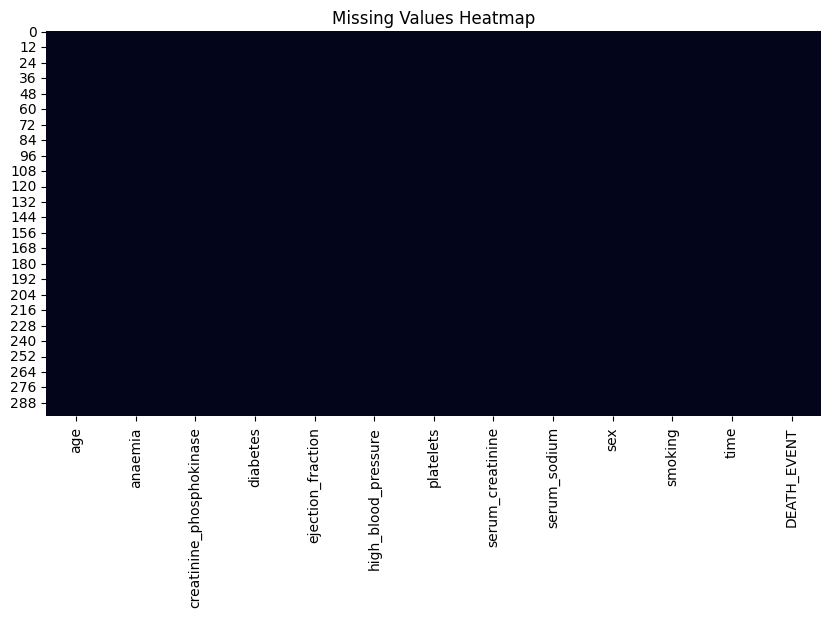

In [4]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

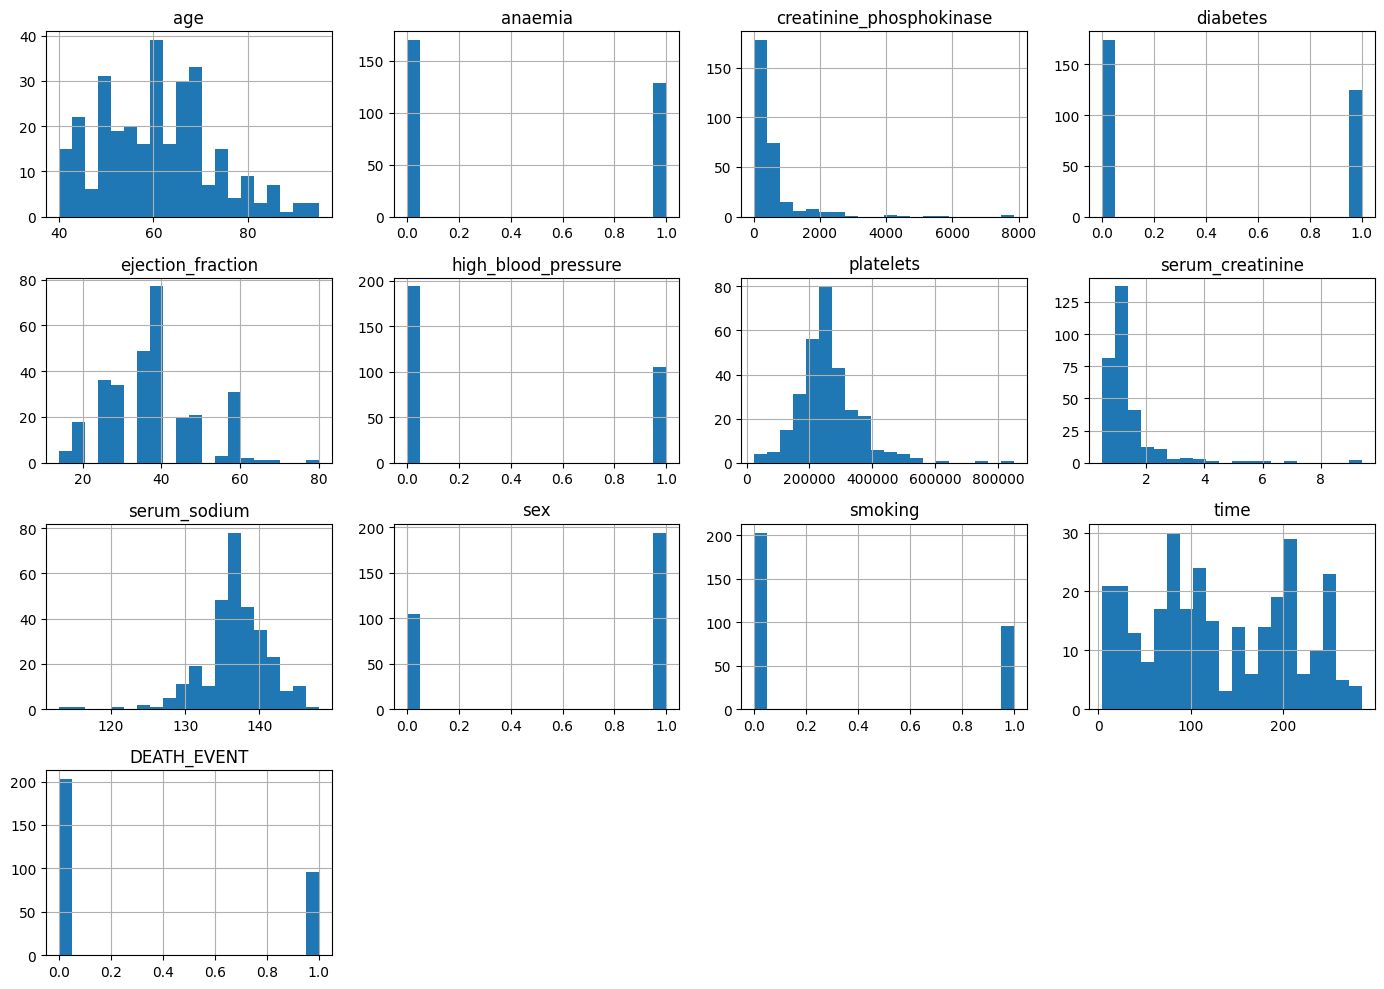

In [5]:
df.hist(figsize=(14, 10), bins=20)

plt.tight_layout()
plt.show()

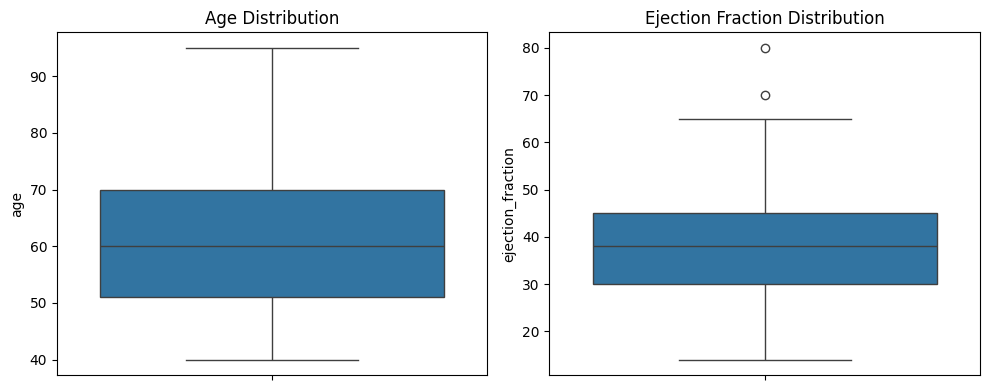

In [6]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["age"])
plt.title("Age Distribution")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["ejection_fraction"])
plt.title("Ejection Fraction Distribution")

plt.tight_layout()
plt.show()

In [7]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [8]:
cat_cols = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
print("Negative values:")
print((df < 0).sum())

Negative values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [10]:
print("Invalid ages:", ((df["age"] < 0) | (df["age"] > 120)).sum())

Invalid ages: 0


In [11]:
df.loc[(df["age"] < 0) | (df["age"] > 120), "age"] = df["age"].median()

In [12]:
outlier_cols = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (224, 13)


In [13]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 60, 120],
    labels=["<40", "40-60", ">60"],
    right=False
)

print(df["age_group"].value_counts())

age_group
>60      125
40-60     99
<40        0
Name: count, dtype: int64


In [14]:
risk = df["ejection_fraction"] * df["serum_creatinine"]

df["risk_score"] = (
    (risk - risk.min()) /
    (risk.max() - risk.min())
)

df[["ejection_fraction", "serum_creatinine", "risk_score"]].head()

,ejection_fraction,serum_creatinine,risk_score
0,20,1.9,0.310545
2,20,1.3,0.171495
3,20,1.9,0.310545
5,40,2.1,0.843569
6,15,1.2,0.078795


In [15]:
df = pd.get_dummies(
    df,
    columns=["age_group"],
    dtype=int
)

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4,1,0.310545,0,0,1
2,65.0,0,146,0,20,0,162000.0,1.3,129,1,1,7,1,0.171495,0,0,1
3,50.0,1,111,0,20,0,210000.0,1.9,137,1,0,7,1,0.310545,0,1,0
5,90.0,1,47,0,40,1,204000.0,2.1,132,1,1,8,1,0.843569,0,0,1
6,75.0,1,246,0,15,0,127000.0,1.2,137,1,0,10,1,0.078795,0,0,1


In [16]:
from sklearn.preprocessing import MinMaxScaler

scale_cols = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time",
    "risk_score"
]

scaler = MinMaxScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [17]:
df[scale_cols].head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,risk_score
0,0.636364,0.470990,0.117647,0.468852,0.866667,0.217391,0.000000,0.310545
2,0.454545,0.098976,0.117647,0.131148,0.466667,0.173913,0.010676,0.171495
3,0.181818,0.069113,0.117647,0.288525,0.866667,0.521739,0.010676,0.310545
5,0.909091,0.014505,0.509804,0.268852,1.000000,0.304348,0.014235,0.843569
6,0.636364,0.184300,0.019608,0.016393,0.400000,0.521739,0.021352,0.078795


In [20]:
original_df = pd.read_csv(
    "/content/heart_failure_clinical_records_dataset.csv"
)

print("BEFORE CLEANING")
print(
    original_df[
        ["age", "ejection_fraction", "serum_creatinine", "platelets"]
    ].agg(["mean", "median", "std"])
)

BEFORE CLEANING
              age  ejection_fraction  serum_creatinine      platelets
mean    60.833893          38.083612           1.39388  263358.029264
median  60.000000          38.000000           1.10000  262000.000000
std     11.894809          11.834841           1.03451   97804.236869


In [19]:
print("\nAFTER CLEANING")
print(
    df[
        ["age", "ejection_fraction", "serum_creatinine", "platelets"]
    ].agg(["mean", "median", "std"])
)


AFTER CLEANING
             age  ejection_fraction  serum_creatinine  platelets
mean    0.378355           0.474090          0.352381   0.438902
median  0.363636           0.470588          0.333333   0.460656
std     0.217202           0.229624          0.218530   0.220176


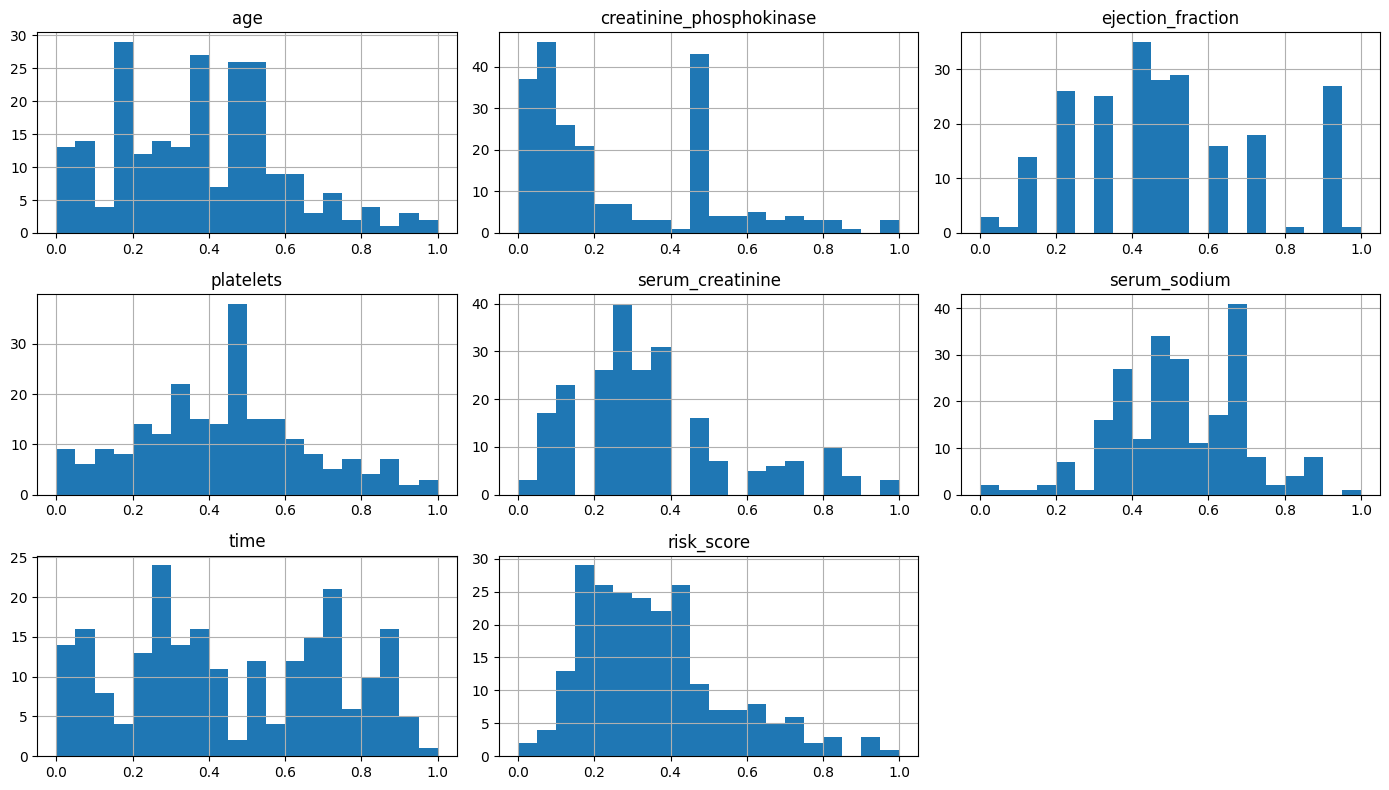

In [21]:
df[scale_cols].hist(figsize=(14, 8), bins=20)

plt.tight_layout()
plt.show()

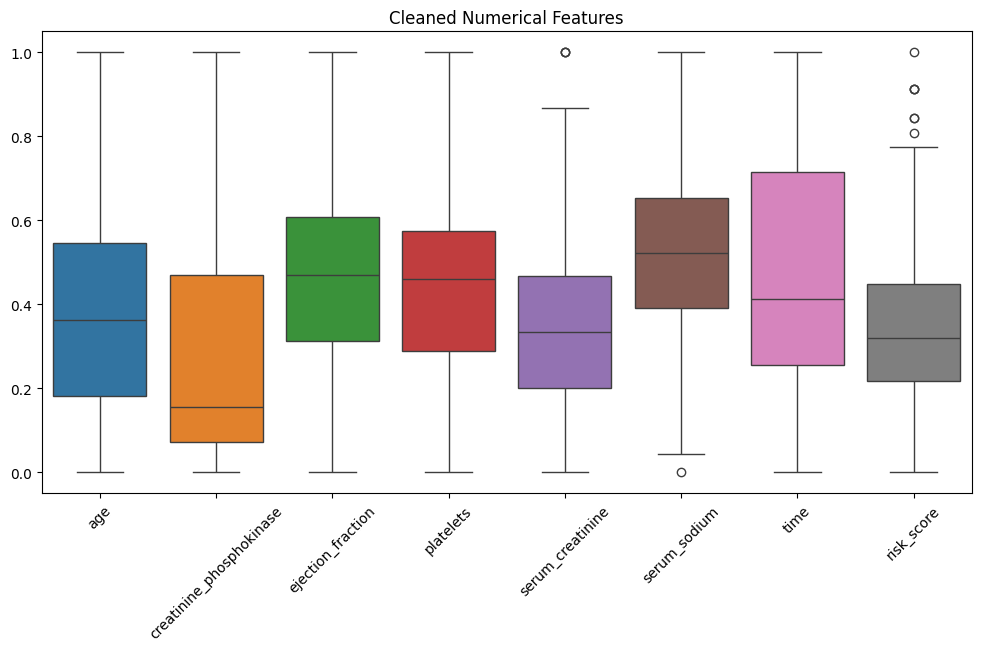

In [22]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[scale_cols])

plt.xticks(rotation=45)
plt.title("Cleaned Numerical Features")
plt.show()

In [23]:
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values after cleaning:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_<40               0
age_group_40-60             0
age_group_>60               0
dtype: int64

Total missing values: 0


In [24]:
df.to_csv("heart_failure_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Final shape:", df.shape)

Cleaned dataset saved successfully!
Final shape: (224, 17)
